In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Theory Min-Max Scaling

[![Chat-GPT-Image-Aug-21-2026-10-57-40-PM.png](https://i.postimg.cc/7ZGZVgp6/Chat-GPT-Image-Aug-21-2026-10-57-40-PM.png)](https://postimg.cc/k2CCMtM3)


In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)
n = 200

# ====================== Base Features ======================

age = np.random.normal(38, 10, n).clip(18, 70).astype(int)

# Income somewhat correlated with age
income = (
    age * 3000
    + np.random.normal(0, 15000, n)
    + 25000
).clip(20000, 300000)

income = np.round(income, -2)

# Spending score correlated with income
spending_score = (
    income / 3500
    + np.random.normal(0, 10, n)
).clip(1, 100).astype(int)

gender = np.random.choice(
    ["Male", "Female", "Other"],
    n,
    p=[0.49, 0.48, 0.03]
)

city = np.random.choice(
    ["Mumbai", "Delhi", "Bangalore", "Hyderabad",
     "Chennai", "Pune", "Kolkata", "Ahmedabad"],
    n,
    p=[0.20, 0.16, 0.14, 0.11, 0.11, 0.10, 0.10, 0.08]
)

# ====================== Membership ======================

membership_prob = np.clip(
    (income - 30000) / 250000,
    0,
    1
)

membership = np.where(
    membership_prob > 0.75,
    "Platinum",
    np.where(
        membership_prob > 0.50,
        "Gold",
        np.where(
            membership_prob > 0.25,
            "Silver",
            "Bronze"
        )
    )
)

# ====================== Target ======================

purchase_count = (
    spending_score * 0.15
    + np.where(
        membership == "Platinum", 10,
        np.where(
            membership == "Gold", 6,
            np.where(
                membership == "Silver", 3, 0
            )
        )
    )
    + np.random.poisson(3, n)
).clip(0, 40).astype(int)

# ====================== Activity ======================

is_active = np.random.choice(
    [True, False],
    n,
    p=[0.80, 0.20]
)

# ====================== Last Purchase ======================

days_ago = np.where(
    is_active,
    np.random.exponential(80, n).clip(1, 300),
    np.random.exponential(200, n).clip(30, 500)
).astype(int)

last_purchase = [
    datetime(2025, 6, 1) - timedelta(days=int(d))
    for d in days_ago
]

# ====================== Feedback ======================

feedback = np.random.choice(
    ["Excellent", "Good", "Average", "Poor"],
    n,
    p=[0.25, 0.40, 0.25, 0.10]
)

# ====================== DataFrame ======================

df = pd.DataFrame({
    "customer_id": range(1001, 1001 + n),
    "age": age,
    "gender": gender,
    "city": city,
    "income": income,
    "spending_score": spending_score,
    "membership": membership,
    "purchase_count": purchase_count,
    "is_active": is_active,
    "last_purchase": last_purchase,
    "feedback": feedback
})

df.head(8)

,customer_id,age,gender,city,income,spending_score,membership,purchase_count,is_active,last_purchase,feedback
0,1001,42,Male,Hyderabad,156400.0,28,Gold,13,False,2024-05-24,Poor
1,1002,36,Female,Mumbai,141400.0,34,Silver,12,True,2025-05-17,Good
2,1003,44,Female,Bangalore,173200.0,49,Gold,15,True,2024-12-29,Good
3,1004,53,Female,Hyderabad,199800.0,57,Gold,16,True,2025-05-12,Excellent
4,1005,35,Female,Delhi,109300.0,26,Silver,9,False,2025-03-29,Good
5,1006,35,Female,Pune,115900.0,39,Silver,14,True,2025-05-06,Poor
6,1007,53,Male,Mumbai,191700.0,44,Gold,12,True,2025-03-11,Good
7,1008,45,Male,Mumbai,167700.0,46,Gold,16,False,2025-02-03,Good


In [3]:
# taking columns that require standardization
df = df.dropna()
cols = ["age", "income", "purchase_count"]
df2 = df[cols]
df2.head()

,age,income,purchase_count
0,42,156400.0,13
1,36,141400.0,12
2,44,173200.0,15
3,53,199800.0,16
4,35,109300.0,9


In [4]:
X = df2.drop("purchase_count", axis = 1)
y = df2['purchase_count']

In [5]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [6]:
X_train.sample(5)

,age,income
192,40,125200.0
167,56,193200.0
83,32,102400.0
41,39,140300.0
157,42,146700.0


# Min Max Scaling

In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)
# Calculates mean and SD
# Also, always fit on X_train not the test data

X_train_Scaled = scaler.transform(X_train)
X_test_Scaled = scaler.transform(X_test)

In [8]:
# Convert into Dataframe

X_train_Scaled = pd.DataFrame(X_train_Scaled, columns = X_train.columns)
X_test_Scaled = pd.DataFrame(X_test_Scaled, columns = X_test.columns)

In [9]:
X_train_Scaled.sample(5)

,age,income
7,0.425532,0.573460
4,0.170213,0.260071
80,0.361702,0.456754
106,0.234043,0.385664
62,0.425532,0.491114


In [19]:
print("Before:")
print(round(X_train.min()))
print(round(X_train.max()))

print("\nAfter:")
print(round(X_train_Scaled.min()))
print(round(X_train_Scaled.max()))

Before:
age          18.0
income    54400.0
dtype: float64
age           65.0
income    223200.0
dtype: float64

After:
age       0.0
income    0.0
dtype: float64
age       1.0
income    1.0
dtype: float64


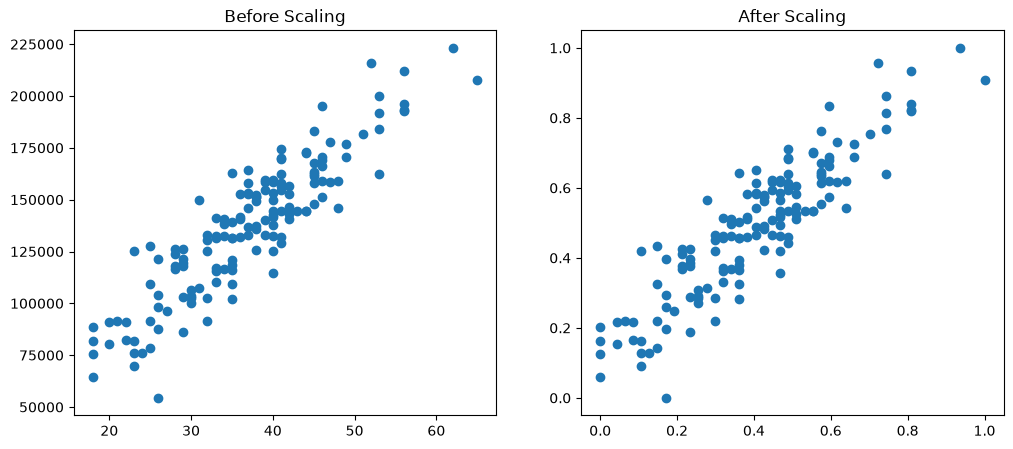

In [11]:
# Visualising the change by scatterplot
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.scatter(X_train["age"], X_train["income"])
ax1.set_title("Before Scaling")

ax2.scatter(X_train_Scaled["age"], X_train_Scaled["income"])
ax2.set_title("After Scaling")

plt.show()

# Observe the X and Y axis

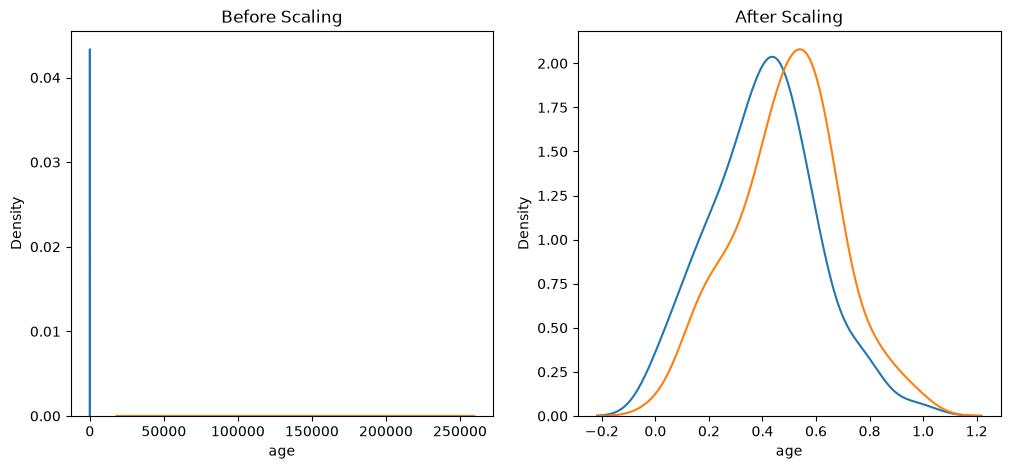

In [12]:
# Visualising the change by Kernal-Density-Estimation Plot
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["age"], ax = ax1)
sns.kdeplot(X_train["income"], ax = ax1)

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_Scaled["age"], ax = ax2)
sns.kdeplot(X_train_Scaled["income"], ax = ax2)

plt.show()

# Observe the X and Y axis

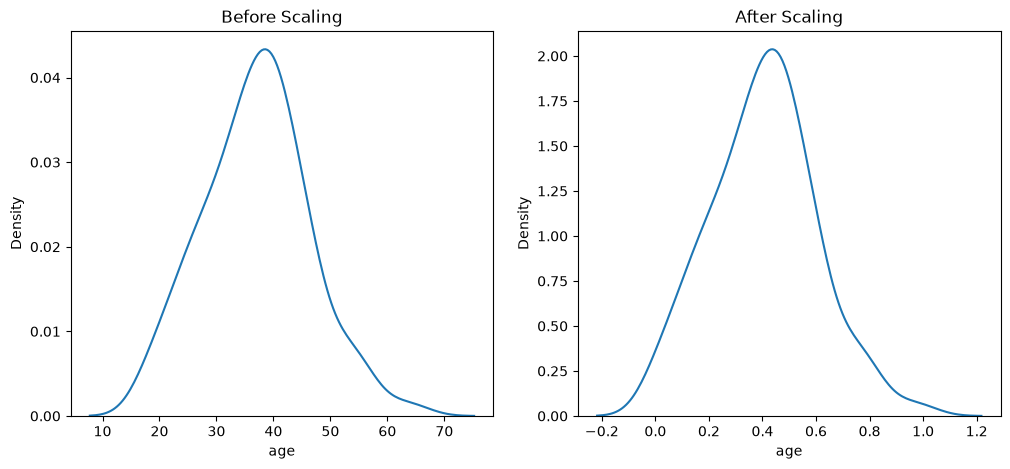

In [13]:
# Visualising the individual change by Kernal-Density-Estimation Plot
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train["age"], ax = ax1)

# After Scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_Scaled["age"], ax = ax2)

plt.show()

# This proves that the distribution remains the same but the scale becomes manageble

# Linear regression can compensate for the scale difference through its coefficients so Normalisation is not required for it

In [14]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr_scaled = LinearRegression()

In [15]:
# Training both scaled and unscaled model
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_Scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 0.19,14.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['age','income']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.489
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [16]:
# Predicting Outputs
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_Scaled)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Before Scaling")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
print("R²  :", r2_score(y_test, y_pred))

print("\nAfter Scaling")
print("MAE :", mean_absolute_error(y_test, y_pred_scaled))
print("RMSE:", mean_squared_error(y_test, y_pred_scaled) ** 0.5)
print("R²  :", r2_score(y_test, y_pred_scaled))

Before Scaling
MAE : 1.991984975605167
RMSE: 2.476132884481726
R²  : 0.5682229534076204

After Scaling
MAE : 1.9919849756051664
RMSE: 2.476132884481725
R²  : 0.5682229534076206


# KNN (Vibe coded for Demonstaration)
KNN Calculates distance between two points, see how scaling improves the performance

In [18]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn_scaled = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)
knn_scaled.fit(X_train_Scaled, y_train)

y_pred_knn = knn.predict(X_test)
y_pred_knn_scaled = knn_scaled.predict(X_test_Scaled)

print("Before Scaling")
print("MAE :", mean_absolute_error(y_test, y_pred_knn))
print("RMSE:", mean_squared_error(y_test, y_pred_knn) ** 0.5)
print("R²  :", r2_score(y_test, y_pred_knn))

print("\nAfter Scaling")
print("MAE :", mean_absolute_error(y_test, y_pred_knn_scaled))
print("RMSE:", mean_squared_error(y_test, y_pred_knn_scaled) ** 0.5)
print("R²  :", r2_score(y_test, y_pred_knn_scaled))

Before Scaling
MAE : 2.156
RMSE: 2.5958428303732104
R²  : 0.5254647887323944

After Scaling
MAE : 2.072
RMSE: 2.629068276024797
R²  : 0.5132394366197184


# Other Methods of Scaling

[![Chat-GPT-Image-Aug-21-2026-11-03-25-PM.png](https://i.postimg.cc/8zJzHhqS/Chat-GPT-Image-Aug-21-2026-11-03-25-PM.png)](https://postimg.cc/w1zzxsqf)

[![Chat-GPT-Image-Aug-21-2026-11-21-18-PM.png](https://i.postimg.cc/9QnJ3j8r/Chat-GPT-Image-Aug-21-2026-11-21-18-PM.png)](https://postimg.cc/sM5pSbRr)